# CSP-9-Distributed : CSP Distribués (DisCSP)

**Navigation** : [<< CSP-8-Temporal](CSP-8-Temporal.ipynb) | [Index](../README.md) | [App-1-NQueens >>](../Applications/CSP/App-1-NQueens.ipynb)

> **Durée estimée** : 2h00

## Objectifs d'apprentissage

À la fin de ce notebook, vous saurez :

1. **Comprendre** les défis de la résolution distribuée de CSP
2. **Implémenter** l'algorithme Asynchronous Backtracking (ABT)
3. **Découvrir** Asynchronous Weak-Commitment (AWC) et ses améliorations
4. **Appliquer** les techniques de privacy-preserving CSP
5. **Résoudre** des problèmes de coordination multi-agent
6. **Comparer** ABT et AWC (benchmark) et **mettre en pratique** les exercices (DisCSP, confidentialite)


In [15]:
# Imports
from dataclasses import dataclass, field
from typing import Dict, List, Set, Tuple, Optional, Any
import random
from datetime import datetime
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

print("Environnement prepare pour les CSP Distribues")

Environnement prepare pour les CSP Distribues


## 1. Formalisation du DisCSP

### Definition

Un **DisCSP** (Distributed Constraint Satisfaction Problem) est defini par :

- **Agents** : $A = \{a_1, a_2, ..., a_n\}$
- **Variables** : Chaque agent $a_i$ controle un sous-ensemble $X_i \subset X$
- **Domaines** : Chaque variable $x_j$ a un domaine $D_j$
- **Contraintes** : $C = C_{interne} \cup C_{externe}$
  - $C_{interne}$ : contraintes entre variables d'un meme agent
  - $C_{externe}$ : contraintes entre variables d'agents differents

### Hypotheses classiques

1. **Un agent = une variable** (simplification courante)
2. **Communication asynchrone** : pas de synchronisation globale
3. **Fiabilite** : pas de perte de messages ; l'ordre de livraison depend du modele (canaux reels vs simulateur).
4. **Ordre total** : priorite entre agents (ABT)

> **Dans ce notebook** : la communication est **simulee** par une **file FIFO globale** dans `ABTSystem` — modele pedagogique proche de *asynchrone fiable* avec un ordre de traitement unique, pas de vrais sockets.


In [16]:
@dataclass
class Message:
    """Message echange entre agents dans un DisCSP."""
    sender: int          # ID de l'agent emetteur
    receiver: int        # ID de l'agent destinataire
    msg_type: str        # 'ok?', 'nogood', 'addlink', 'stop'
    content: Any         # Contenu du message
    timestamp: float = field(default_factory=lambda: datetime.now().timestamp())
    
    def __repr__(self):
        return f"Message({self.sender}->{self.receiver}, {self.msg_type})"


@dataclass
class Nogood:
    """Nogood : ensemble d'assignations incoherentes."""
    assignments: Dict[int, Any]  # {var_id: value}
    
    def __repr__(self):
        pairs = [f"x{v}={val}" for v, val in self.assignments.items()]
        return f"NG({', '.join(pairs)})"
    
    def __hash__(self):
        return hash(tuple(sorted(self.assignments.items())))
    
    def __eq__(self, other):
        return self.assignments == other.assignments
print("Classes Message et Nogood definies.")


Classes Message et Nogood definies.


## 2. Asynchronous Backtracking (ABT)

### Principe

ABT (Yokoo, Durfee, Ishida, Kuwabara, 1992) est l'algorithme de reference pour DisCSP :

1. **Ordre total** : Les agents sont ordonnes $a_1 < a_2 < ... < a_n$
2. **Propagation avant** : Les agents de haute priorite envoient leurs valeurs
3. **Nogoods** : Les agents de basse priorite generent des explications d'echec
4. **Asynchronie** : Chaque agent traite les messages independamment

### Types de messages ABT

| Message | Direction | Contenu |
|---------|-----------|---------|
| `ok?` | Haute -> Basse priorite | Assignation courante |
| `nogood` | Basse -> Haute priorite | Contrainte apprise |
| `addlink` | Basse -> Haute priorite | Demande de connexion |
| `stop` | N'importe quel agent | **Echec global** (ex. plus de backtrack possible) ; le **succes** ici = quiescence + verifs, pas un message `stop` |

In [17]:
class ABTAgent:
    """
    Agent pour l'algorithme Asynchronous Backtracking.
    
    Base sur Yokoo et al. (1992)
    """
    
    def __init__(self, agent_id: int, domain: List[Any], 
                 constraint_func, neighbors: List[int]):
        self.id = agent_id
        self.domain = domain
        self.constraint_func = constraint_func  # Fonction de contrainte locale
        self.neighbors = neighbors
        
        # Etat de l'agent
        self.value = None
        self.agent_view: Dict[int, Any] = {}  # Vue des agents de haute priorite
        self.nogoods: Set[Nogood] = set()     # Nogoods appris
        self.higher_priority: List[int] = []  # Agents de haute priorite
        self.lower_priority: List[int] = []   # Agents de basse priorite
        
        # File de messages
        self.message_queue: List[Message] = []
        
        # Statistiques (nogoods_generated : nogoods emis dans _backtrack, pas recus)
        self.messages_sent = 0
        self.nogoods_generated = 0
        self._system = None  # Renseigne par ABTSystem pour AWC / reordonnancement

    def priority_sort_key(self) -> Tuple[float, int]:
        """Cle de tri pour l'ordre entre agents (ABT pur : identique a l'id)."""
        return (float(self.id), self.id)

    def set_priority_order(self, higher: List[int], lower: List[int]):
        """Definit l'ordre de priorite des agents."""
        self.higher_priority = higher
        self.lower_priority = lower
    
    def check_consistency(self, value: Any) -> bool:
        """
        Coherence locale : contraintes avec chaque agent deja present dans agent_view
        (en pratique : agents de priorite superieure ayant envoye un ok?).
        Quand la file de messages est vide, la vue contient tous les voisins prioritaires :
        la coherence locale coincide alors avec les aretes du graphe pour cet agent.
        """
        for var_id, val in self.agent_view.items():
            if not self.constraint_func(self.id, value, var_id, val):
                return False
        
        # Verifier avec les nogoods
        for nogood in self.nogoods:
            # Si le nogood est applicable (toutes les vars dans agent_view)
            if self._nogood_applicable(nogood, value):
                return False
        
        return True
    
    def _nogood_applicable(self, nogood: Nogood, value: Any) -> bool:
        """Le nogood contient self avec une certaine valeur, et toutes les autres
        variables de priorite superieure doivent coincider avec agent_view."""
        if self.id not in nogood.assignments:
            return False
        if nogood.assignments[self.id] != value:
            return False
        for v, v_val in nogood.assignments.items():
            if v == self.id:
                continue
            if self.agent_view.get(v) != v_val:
                return False
        return True
    
    def choose_value(self) -> Optional[Any]:
        """Choisit une valeur coherente avec l'agent_view."""
        for val in self.domain:
            if self.check_consistency(val):
                return val
        return None
    
    def process_ok_message(self, msg: Message):
        """Traite un message 'ok?' (assignation d'un agent de haute priorite)."""
        var_id, value = msg.content
        self.agent_view[var_id] = value

        if self.value is None:
            self.value = self.choose_value()
            if self.value is not None:
                return self._send_ok_messages()
            return self._backtrack()

        if not self.check_consistency(self.value):
            self.value = self.choose_value()
            if self.value is not None:
                return self._send_ok_messages()
            return self._backtrack()
        return []
    
    def process_nogood_message(self, msg: Message) -> List[Message]:
        """Traite un message 'nogood' (contrainte apprise)."""
        nogood = msg.content
        self.nogoods.add(nogood)
        
        # Liens manquants : tout agent du nogood pas encore dans la vue doit envoyer addlink
        new_links = []
        for var_id in nogood.assignments:
            if var_id != self.id and var_id not in self.agent_view:
                if var_id not in self.higher_priority:
                    self.higher_priority.append(var_id)
                new_links.append(var_id)
        
        messages = []
        
        # Envoyer addlink si necessaire
        for var_id in new_links:
            messages.append(Message(
                sender=self.id,
                receiver=var_id,
                msg_type='addlink',
                content=self.id
            ))
            self.messages_sent += 1
        
        # Verifier la valeur courante
        value_changed = False
        if self.value is not None and not self.check_consistency(self.value):
            old_value = self.value
            self.value = self.choose_value()
            value_changed = (self.value != old_value)
            if self.value is not None:
                messages.extend(self._send_ok_messages())
            else:
                messages.extend(self._backtrack())

        # Si la valeur n'a pas change, renvoyer un ok? a l'expediteur :
        # il a probablement retire self de son agent_view en backtrackant et doit
        # recuperer la valeur courante (sinon il peut converger sur un etat global incoherent).
        if not value_changed and self.value is not None and msg.sender != self.id:
            messages.append(Message(
                sender=self.id,
                receiver=msg.sender,
                msg_type='ok?',
                content=(self.id, self.value),
            ))
            self.messages_sent += 1

        return messages
    
    def _send_ok_messages(self) -> List[Message]:
        """Envoie la valeur courante aux agents de basse priorite."""
        messages = []
        for neighbor in self.lower_priority:
            messages.append(Message(
                sender=self.id,
                receiver=neighbor,
                msg_type='ok?',
                content=(self.id, self.value)
            ))
            self.messages_sent += 1
        return messages
    
    def _backtrack(self) -> List[Message]:
        """ABT standard : nogood ne contenant que des agents de priorite superieure
        (ceux que la cible peut voir), envoye au plus bas prioritaire parmi ceux-la,
        puis on oublie sa valeur et on re-essaie une affectation locale."""
        relevant = {v: self.agent_view[v] for v in self.higher_priority if v in self.agent_view}
        if not relevant:
            return [Message(
                sender=self.id,
                receiver=-1,
                msg_type='stop',
                content='no_solution'
            )]

        target = max(relevant.keys())
        nogood = Nogood(relevant)
        messages: List[Message] = [Message(
            sender=self.id,
            receiver=target,
            msg_type='nogood',
            content=nogood,
        )]
        self.messages_sent += 1
        self.nogoods_generated += 1

        self.agent_view.pop(target, None)
        self.value = self.choose_value()
        if self.value is not None:
            messages.extend(self._send_ok_messages())
        else:
            messages.extend(self._backtrack())
        return messages
    
    def initialize(self) -> List[Message]:
        """Initialise l'agent et envoie les premiers messages."""
        self.value = self.choose_value()
        if self.value is not None:
            return self._send_ok_messages()
        return self._backtrack()
print("Classe ABTAgent definie.")


Classe ABTAgent definie.


### Implementation du systeme ABT

Cette section implemente la classe `ABTSystem` qui simule la communication asynchrone entre agents. Le systeme gere la file de messages, orchestre le traitement des messages ABT (ok?, nogood, addlink, stop) et verifie la convergence vers une solution.

**Composantes principales** :

- **Gestion des messages** : File FIFO pour simuler l'asynchronie
- **Ordre de priorite** : avec `ABTAgent` pur, ordre fixe selon les ids (0 < 1 < 2 < ...) ; avec `AWCAgent` (section 3), l'ordre est **recalcule** via `priority_sort_key()` / `_on_awc_reorder()` dans le meme `ABTSystem`.
- **Detection de solution** : Apres **quiescence** (file vide), verification de la coherence locale **et** des contraintes sur **toutes** les aretes (`_verify_global_constraints`)
- **addlink** : L'agent sollicite renvoie un `ok?` avec sa valeur courante pour completer la vue de l'emetteur
- **Statistiques** : Comptage des messages et nogoods echanges

In [18]:
class ABTSystem:
    """
    Systeme de simulation pour l'algorithme ABT.
    Simule la communication asynchrone entre agents.
    """
    
    def __init__(self, agents: Dict[int, ABTAgent]):
        self.agents = agents
        self.message_queue: List[Message] = []
        self.solution: Optional[Dict[int, Any]] = None
        self.no_solution = False
        self.total_messages = 0
        self.total_nogoods = 0
        self.message_type_counts: Dict[str, int] = {}  # rempli a chaque run() : types traites dans la file FIFO

        for ag in self.agents.values():
            ag._system = self

        self._setup_priority_order()

    def _setup_priority_order(self):
        """Configure higher/lower selon priority_sort_key() de chaque agent (ABT ou AWC)."""
        agent_ids = sorted(self.agents.keys(), key=lambda i: self.agents[i].priority_sort_key())
        for i, agent_id in enumerate(agent_ids):
            higher = agent_ids[:i]
            lower = agent_ids[i + 1:]
            self.agents[agent_id].set_priority_order(higher, lower)

    def _on_awc_reorder(self):
        """Apres promotion AWC : recalcul des priorites + nouvelle vague de ok?."""
        self._setup_priority_order()
        for ag in self.agents.values():
            if ag.value is not None:
                self.message_queue.extend(ag._send_ok_messages())
    
    def run(self, max_iterations: int = 10000) -> Optional[Dict[int, Any]]:
        """
        Execute ABT jusqu'a quiescence (file vide), puis valide la solution.
        On ne declare le succes qu'apres vidage de la file : sinon des ok? peuvent
        encore modifier les vues et donner une fausse coherence locale.
        """
        self.message_type_counts = {}
        for agent in self.agents.values():
            messages = agent.initialize()
            self.message_queue.extend(messages)

        iteration = 0
        while iteration < max_iterations:
            if not self.message_queue:
                if self.no_solution:
                    return None
                if self._check_solution() and self._verify_global_constraints():
                    self.solution = {a.id: a.value for a in self.agents.values()}
                    return self.solution
                break

            msg = self.message_queue.pop(0)
            self.total_messages += 1
            self.message_type_counts[msg.msg_type] = self.message_type_counts.get(msg.msg_type, 0) + 1

            if msg.msg_type == 'stop':
                self.no_solution = True
                return None

            receiver = self.agents.get(msg.receiver)
            if receiver:
                if msg.msg_type == 'ok?':
                    new_messages = receiver.process_ok_message(msg)
                elif msg.msg_type == 'nogood':
                    new_messages = receiver.process_nogood_message(msg)
                    self.total_nogoods += 1
                elif msg.msg_type == 'addlink':
                    # L'agent de haute priorite renvoie son assignement courant au demandeur
                    requester = msg.content
                    new_messages = []
                    if receiver.value is not None:
                        new_messages.append(Message(
                            sender=receiver.id,
                            receiver=requester,
                            msg_type='ok?',
                            content=(receiver.id, receiver.value)
                        ))
                        receiver.messages_sent += 1
                else:
                    new_messages = []

                self.message_queue.extend(new_messages)

            iteration += 1

        return None

    def _check_solution(self) -> bool:
        """Tous les agents ont une valeur et sont localement coherents avec leur vue."""
        for agent in self.agents.values():
            if agent.value is None:
                return False
            if not agent.check_consistency(agent.value):
                return False
        return True

    def _verify_global_constraints(self) -> bool:
        """Verifie chaque arete du graphe (via les listes de voisins des agents)."""
        assignment = {a.id: a.value for a in self.agents.values()}
        if any(v is None for v in assignment.values()):
            return False
        seen_edges: Set[Tuple[int, int]] = set()
        for aid, agent in self.agents.items():
            for nb in agent.neighbors:
                edge = tuple(sorted((aid, nb)))
                if edge in seen_edges:
                    continue
                seen_edges.add(edge)
                if not agent.constraint_func(aid, assignment[aid], nb, assignment[nb]):
                    return False
        return True
    
    def get_statistics(self) -> Dict:
        """Retourne les statistiques d'execution."""
        return {
            'total_messages': self.total_messages,
            'total_nogoods': self.total_nogoods,
            'solution_found': self.solution is not None,
            'solution': self.solution
        }
print("Classe ABTSystem definie.")


Classe ABTSystem definie.


### Analyse de l'implementation ABT

**Architecture de l'agent ABT** :

| Methode | Responsabilite | Cle pour ABT |
|---------|----------------|--------------|
| `check_consistency()` | Verifie la coherence avec agent_view et nogoods | Coeur de la coherence locale |
| `choose_value()` | Selectionne une valeur coherente | Heuristique de choix |
| `process_ok_message()` | Traite les assignations des agents de haute priorite | Propagation avant |
| `process_nogood_message()` | Traite les contraintes apprise | Apprentissage |
| `_backtrack()` | Construit un nogood (seulement des priorites superieures), l'envoie au plus bas prioritaire parmi elles, retire la cible de la vue et tente une nouvelle valeur | Resolution de conflits |
| `_send_ok_messages()` | Propage la valeur aux agents de basse priorite | Communication |

**Architecture du systeme ABT** :

| Methode | Responsabilite |
|---------|----------------|
| `_setup_priority_order()` | Etablit l'ordre de priorite statique entre agents |
| `run()` | Boucle principale de traitement des messages |
| `_check_solution()` | Coherence locale (valeur + vue + nogoods) pour chaque agent |
| `_verify_global_constraints()` | Controle explicite de chaque arete du graphe (filet de securite pedagogique) |

**Limitations de cette implementation** :

1. **ABT pur (`ABTAgent`)** : ordre de priorite fixe entre ids ; le variant **AWC** (section 3) modifie dynamiquement la priorite dans ce notebook.
2. **ABT suffisamment complet pour le cours** : nogoods restreints aux priorites superieures, cible correcte (plus bas prioritaire parmi elles), re-tentative apres retrait de la cible, `addlink` reel et **renvoi d'`ok?` par le destinataire d'un nogood quand sa valeur ne change pas** (evite les incoherences globales). C'est proche de l'ABT de Yokoo et al. (1992) sans pretendre remplacer une preuve formelle.
3. **Pas de detection de cycles** : La boucle est bornee par `max_iterations`

**Points forts pedagogiques** :

- Code lisible et bien structure
- Separe clairement les responsabilites
- Illustre le flux de messages ABT avec quiescence avant succes
- Verification globale des aretes pour relier algorithme distribue et CSP sous-jacent

> **Note** : L'objectif reste pedagogique. Une implementation industrielle ajouterait robustesse, optimisations et garanties formelles supplementaires.

### Exemple : Coloration de graphe distribuee

Considerons un probleme de coloration de graphe ou chaque noeud est un agent independant.

In [19]:
# Exemple : Coloration de graphe 4-noeuds, 3 couleurs

# Graphe : 0-1, 1-2, 2-3, 3-0 (cycle)
graph_edges = [(0, 1), (1, 2), (2, 3), (3, 0)]
colors = ['R', 'G', 'B']

# Fonction de contrainte : deux noeuds adjacents doivent avoir des couleurs differentes
def graph_coloring_constraint(var1, val1, var2, val2):
    edge = (min(var1, var2), max(var1, var2))
    if edge in [(min(e[0], e[1]), max(e[0], e[1])) for e in graph_edges]:
        return val1 != val2
    return True  # Pas de contrainte si non adjacents

# Creer les agents
agents = {}
for i in range(4):
    neighbors = [n for e in graph_edges for n in e if i in e and n != i]
    agents[i] = ABTAgent(
        agent_id=i,
        domain=colors.copy(),
        constraint_func=graph_coloring_constraint,
        neighbors=neighbors
    )

# Executer ABT
system = ABTSystem(agents)
solution = system.run()

print("=== Resultat ABT ===")
print(f"Solution: {solution}")
print(f"Statistiques: {system.get_statistics()}")

# Verifier la solution
if solution:
    print("\nVerification:")
    for v1, v2 in graph_edges:
        c1, c2 = solution[v1], solution[v2]
        ok = c1 != c2
        print(f"  Arete {v1}-{v2}: {c1} vs {c2} -> {'OK' if ok else 'ECHEC'}")

=== Resultat ABT ===
Solution: {0: 'R', 1: 'G', 2: 'R', 3: 'B'}
Statistiques: {'total_messages': 10, 'total_nogoods': 0, 'solution_found': True, 'solution': {0: 'R', 1: 'G', 2: 'R', 3: 'B'}}

Verification:
  Arete 0-1: R vs G -> OK
  Arete 1-2: G vs R -> OK
  Arete 2-3: R vs B -> OK
  Arete 3-0: B vs R -> OK


### Interpretation : Analyse de la solution ABT

**Comportement attendu apres correction du simulateur** :

1. **Quiescence** : On ne conclut a une solution qu'une fois la **file de messages vide**, pour que chaque agent ait recu les `ok?` de tous ses voisins de **priorite superieure** et ait ajuste sa valeur si besoin.
2. **Double verification** : `_check_solution()` garantit la coherence **locale** (valeur compatible avec `agent_view` et nogoods) ; `_verify_global_constraints()` parcourt **chaque arete** du graphe avec la meme fonction de contrainte que les agents — ce qui relie clairement le DisCSP au CSP sous-jacent.
3. **addlink** : Si un nogood mentionne un agent dont la valeur manque encore dans la vue, l'emetteur envoie `addlink` et l'agent de haute priorite repond par un `ok?` (comportement pedagogique simplifie mais coherent avec l'idee de completer les liens).

**Ce que vous observez sur la coloration du cycle C4** :

- Une coloration **valide** avec 3 couleurs (le graphe est 2-colorable seulement si biparti ; ici le cycle est pair, donc 2 couleurs suffisent — avec 3 couleurs il existe toujours une solution).
- La cellule de verification (`Arete u-v`) doit afficher **OK** pour toutes les aretes si `solution` n'est pas `None`.

**Point pedagogique** : La coherence locale avec la seule `agent_view` ne suffit pas a prouver la satisfaction globale tant que des messages sont encore en transit ; d'ou la quiescence et le controle explicite des aretes dans `ABTSystem`.

### Visualisation de la communication ABT

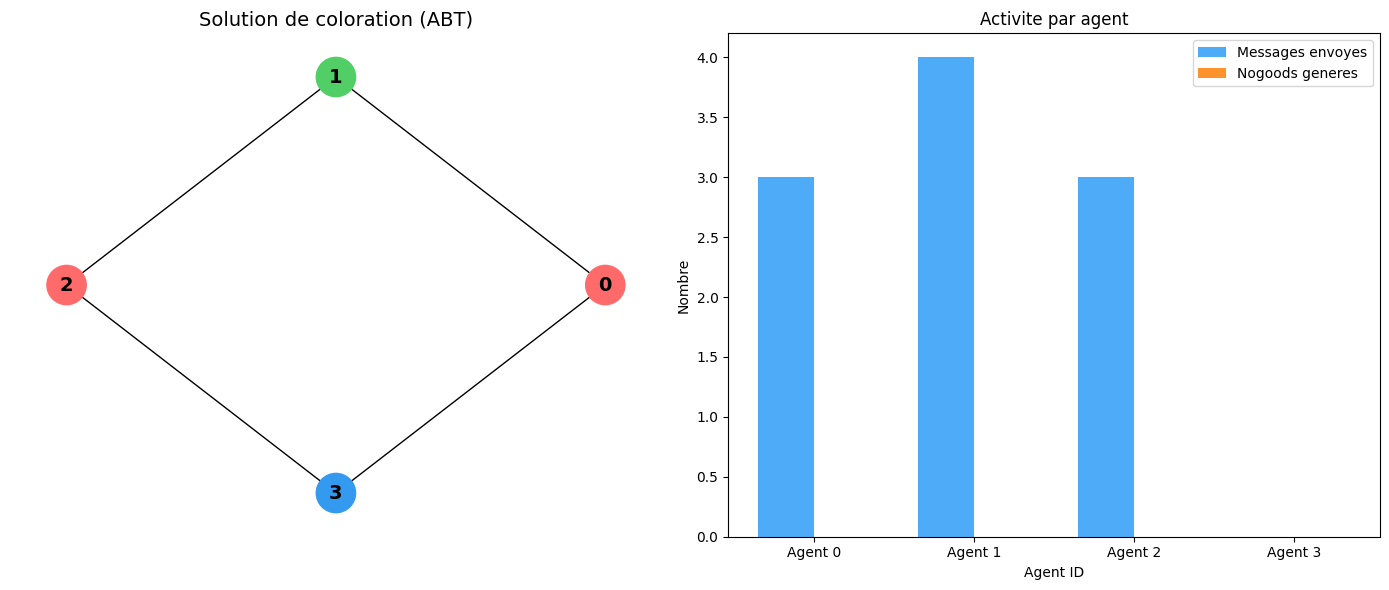

In [20]:
def visualize_abt_communication(
    agents: Dict[int, ABTAgent],
    solution: Dict[int, Any],
    edges: List[Tuple[int, int]],
):
    """Visualise le graphe de contraintes, la solution et l'activite par agent."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Graphe de contraintes avec solution
    ax1 = axes[0]
    G = nx.Graph()
    G.add_nodes_from(agents.keys())
    G.add_edges_from(edges)
    
    color_map = {'R': '#ff6b6b', 'G': '#51cf66', 'B': '#339af0'}
    node_colors = [color_map[solution[n]] for n in G.nodes()]
    
    pos = nx.circular_layout(G)
    nx.draw(G, pos, ax=ax1, with_labels=True, node_color=node_colors,
            node_size=800, font_size=14, font_weight='bold')
    ax1.set_title('Solution de coloration (ABT)', fontsize=14)
    
    # Statistiques par agent
    ax2 = axes[1]
    agent_ids = list(agents.keys())
    messages = [agents[i].messages_sent for i in agent_ids]
    nogoods = [agents[i].nogoods_generated for i in agent_ids]
    
    x = np.arange(len(agent_ids))
    width = 0.35
    
    ax2.bar(x - width/2, messages, width, label='Messages envoyes', color='#4dabf7')
    ax2.bar(x + width/2, nogoods, width, label='Nogoods generes', color='#ff922b')
    
    ax2.set_xlabel('Agent ID')
    ax2.set_ylabel('Nombre')
    ax2.set_title('Activite par agent')
    ax2.set_xticks(x)
    ax2.set_xticklabels([f'Agent {i}' for i in agent_ids])
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

if solution:
    visualize_abt_communication(agents, solution, graph_edges)

### Interpretation de la visualisation

**Graphe de coloration** (gauche) :
- Les noeuds representent les agents 0, 1, 2, 3
- Les couleurs indiquent la valeur choisie par chaque agent apres quiescence
- Les aretes montrent les contraintes : **deux voisins adjacents doivent avoir des couleurs differentes**

**Statistiques par agent** (droite) :
- **Messages envoyes** : Depend du nombre de `ok?` / reassignations (souvent plus qu'un seul message par agent une fois la file drainee)
- **Nogoods generes** : Nombre de nogoods **emis** par l'agent dans `_backtrack()` (compteur `nogoods_generated`). Peut rester a 0 sur cette instance facile si les revisions locales suffisent

**Ce que cette visualisation illustre** :

1. **Propagation** : Les agents de haute priorite imposent des contraintes aux suivants via `ok?`
2. **Solution globale** : Le dessin doit montrer une coloration **legale** du cycle (pas deux couleurs identiques sur une arete)
3. **Charge de communication** : Comparaison visuelle du travail par agent

> **Note** : La simulation reste pedagogique ; les courbes de messages refletent notre file FIFO et notre ordre d'initialisation, pas un deploiement reel sur un reseau.

## 3. Asynchronous Weak-Commitment (AWC)

### Limites d'ABT

ABT souffre de plusieurs problemes :

1. **Ordre fixe** : La priorite statique peut mener a des blocages
2. **Explosion de nogoods** : Beaucoup de nogoods redondants
3. **Goulot d'etranglement** : Les agents de haute priorite ralentissent tout le monde

### Principe d'AWC

AWC (Yokoo, 1995) introduit l'idee de **reordonnancement dynamique** :

- Un agent qui genere un nogood peut **monter en priorite**
- L'ordre n'est plus fixe mais **s'adapte** a la difficulte du probleme
- Meilleure performance sur les instances difficiles

### Comparaison ABT vs AWC

| Caracteristique | ABT | AWC |
|-----------------|-----|-----|
| Ordre agents | Fixe | Dynamique |
| Nogoods | Accumules | Minimises |
| Performance instances faciles | Bonne | Similaire |
| Performance instances difficiles | Mauvaise | Bonne |
| Complexite implementation | Simple | Moyenne |

In [21]:
class AWCAgent(ABTAgent):
    """
    Couche pedagogique AWC au-dessus d'ABT : rang dynamique awc_rank utilise par
    ABTSystem.priority_sort_key pour reorder higher/lower. Ce n'est pas AWC complet
    (Yokoo 1995) mais le reordonnancement impacte reellement la simulation.
    """

    def __init__(self, agent_id: int, domain: List[Any],
                 constraint_func, neighbors: List[int]):
        super().__init__(agent_id, domain, constraint_func, neighbors)
        self.awc_rank = float(agent_id)
        self.nogoods_received = 0  # nogoods recus (voir process_nogood_message)

    def priority_sort_key(self) -> Tuple[float, int]:
        return (self.awc_rank, self.id)

    def process_nogood_message(self, msg: Message) -> List[Message]:
        """Apres traitement ABT : compte les nogoods recus ; promotion si blocage repete."""
        result = super().process_nogood_message(msg)
        self.nogoods_received += 1
        if self.nogoods_received > 3:
            self._increase_priority()
            self.nogoods_received = 0
        return result

    def _increase_priority(self):
        """Monter dans la hierarchie : diminuer awc_rank, puis synchroniser via le systeme."""
        self.awc_rank -= 1.0
        sys = getattr(self, '_system', None)
        if sys is not None:
            sys._on_awc_reorder()

    def _backtrack(self) -> List[Message]:
        if self.higher_priority:
            self._increase_priority()
        return super()._backtrack()

print("Classe AWCAgent definie.")


Classe AWCAgent definie.


### Analyse de l'extension AWC

**Ajouts par rapport a ABT** :

| Methode/Attribut | Role | Impact |
|------------------|------|--------|
| `awc_rank` | Rang dynamique (plus il est petit, plus l'agent est prioritaire) | Cle de tri pour le systeme |
| `nogoods_received` | Nogoods **recus** depuis la derniere promotion | Heuristique de blocage |
| `priority_sort_key()` | Retourne `(awc_rank, id)` | `ABTSystem` en deduit `higher_priority` / `lower_priority` |
| `_increase_priority()` | Diminue `awc_rank`, appelle `_on_awc_reorder()` | Ordre global mis a jour + vague de `ok?` |
| Surcharge de `process_nogood_message()` | Promotion apres > 3 nogoods recus | Adaptation dynamique |
| Surcharge de `_backtrack()` | Promotion avant envoi du nogood ABT | Strategie proactive |

**Strategie de reordonnancement** :

```python
if self.nogoods_received > 3:
    self._increase_priority()
```

Heuristique : un agent qui **recoit** souvent des nogoods est sans doute mal classe ; on diminue son `awc_rank` pour le faire passer avant d'autres dans le tri.

**Exemple de scenario** (simplifie) :

1. Au depart, `awc_rank = float(id)` : meme ordre qu'ABT.
2. Un agent recoit plusieurs nogoods consecutifs ; apres le 4e, `awc_rank -= 1`.
3. `ABTSystem._on_awc_reorder()` recalcule les priorites et renvoie des `ok?` pour rafraichir les `agent_view`.
4. En repetant la promotion, l'agent peut depasser les autres en priorite (rangs decroissants) et **imposer** sa valeur plus tot.

**Avantages d'AWC** :

- **Adaptatif** : L'ordre des agents s'adapte a la difficulte du probleme
- **Moins de nogoods** : Les agents difficiles montent en priorite et imposent leur choix
- **Meilleure convergence** : Sur les problemes difficiles, AWC est souvent plus rapide qu'ABT

**Inconvenients d'AWC** :

- **Complexite** : Plus difficile a implementer et deboguer
- **Instabilite** : L'ordre changeant peut creer des cycles
- **Overhead** : Le reordonnancement a un cout computationnel

> **Note** : Ce n'est pas l'AWC complet de Yokoo (1995), mais le **reordonnancement modifie reellement** le simulateur ABT. Une version complete gererait weak-commitment, les cycles et des heuristiques plus fines.

## 4. Privacy-Preserving CSP

### Motivation

Dans de nombreux scenarios, les agents ne veulent pas reveler leurs contraintes ou preferences :

- **Encheres** : Ne pas reveler son prix de reserve
- **Negociations** : Garder secretes ses zones de flexibilite
- **Medical** : Confidentialite des donnees patients
- **Business** : Protection des donnees commerciales

### Techniques de protection

1. **Chiffrement partiel** : Reveler seulement si necessaire
2. **Secure Multi-Party Computation (SMPC)** : Calculer sans reveler
3. **Pseudonymisation** : Masquer les identites reelles
4. **Aggregation differentielle** : Ajouter du bruit

In [22]:
# Cles pedagogiques : evaluation locale chez le proprietaire vs tiers sans acces.
OWNER_EVAL_KEY = b'__owner__'
PEER_REVEAL_KEY = b'__peer_revealed__'


@dataclass
class PrivateConstraint:
    """
    Contrainte sensible : valeurs interdites connues du proprietaire.
    `encrypted_params` simule une enveloppe (en production : chiffrement authentifie).
    """
    agent_id: int
    constraint_type: str
    encrypted_params: bytes
    public_hint: str
    forbidden_values: frozenset = field(default_factory=frozenset)

    @staticmethod
    def demo(agent_id: int, ctype: str, forbidden: Set[Any], public_hint: str) -> 'PrivateConstraint':
        enc = ','.join(sorted(str(x) for x in forbidden)).encode('utf-8')
        return PrivateConstraint(
            agent_id=agent_id,
            constraint_type=ctype,
            encrypted_params=enc,
            public_hint=public_hint,
            forbidden_values=frozenset(forbidden),
        )

    def evaluate(self, value: Any, key: Optional[bytes] = None) -> bool:
        if key in (OWNER_EVAL_KEY, PEER_REVEAL_KEY):
            return value not in self.forbidden_values
        if key is None:
            # Tiers sans cle : pas d'oracle sur la contrainte (ne pas fuiter accept/refus precis)
            return True
        return value not in self.forbidden_values


class PrivacyPreservingAgent(ABTAgent):
    """
    Agent ABT : contraintes publiques via ok?/nogood ; contraintes privees evaluees
    localement avec OWNER_EVAL_KEY (le proprietaire connait ses interdits sans les diffuser).
    """

    _REVEAL_CAP = {'high': 0, 'medium': 2, 'low': 99}

    def __init__(self, agent_id: int, domain: List[Any],
                 constraint_func, neighbors: List[int],
                 privacy_level: str = 'high'):
        super().__init__(agent_id, domain, constraint_func, neighbors)
        self.privacy_level = privacy_level
        self.private_constraints: List[PrivateConstraint] = []
        self.revealed_info: Set[int] = set()

    def check_consistency(self, value: Any) -> bool:
        if not super().check_consistency(value):
            return False
        for c in self.private_constraints:
            if not c.evaluate(value, key=OWNER_EVAL_KEY):
                return False
        return True

    def reveal_constraint_to(self, agent_id: int) -> bool:
        """Enregistre un pair autorise a utiliser PEER_REVEAL_KEY (plafonne selon privacy_level)."""
        cap = self._REVEAL_CAP.get(self.privacy_level, 0)
        if agent_id in self.revealed_info:
            return True
        if len(self.revealed_info) >= cap:
            return False
        self.revealed_info.add(agent_id)
        return True

    def get_privacy_report(self) -> Dict:
        return {
            'privacy_level': self.privacy_level,
            'agents_with_access': sorted(self.revealed_info),
            'private_constraints_count': len(self.private_constraints),
            'public_hints': [c.public_hint for c in self.private_constraints],
            'note': "Les affectations de creneaux sont visibles dans les messages ok? ; les ensembles interdits internes ne sont pas envoyes.",
        }

print("Classes PrivateConstraint et PrivacyPreservingAgent definies.")


Classes PrivateConstraint et PrivacyPreservingAgent definies.


### Analyse de l'implementation privacy-preserving

**Classes pour la protection de la vie privee** :

| Classe | Responsabilite | Technique de protection |
|--------|----------------|-------------------------|
| `PrivateConstraint` | Interdits sensibles + enveloppe `encrypted_params` (demo) | Evaluation avec `OWNER_EVAL_KEY` / `PEER_REVEAL_KEY` |
| `PrivacyPreservingAgent` | ABT + contraintes locales privees | `check_consistency` appelle `evaluate(..., OWNER_EVAL_KEY)` |

**Mecanisme** :

- Chez le **proprietaire**, `check_consistency` utilise `OWNER_EVAL_KEY` : les valeurs dans `forbidden_values` sont **appliquees** sans etre envoyees aux autres agents.
- Avec `key is None`, un **tiers** ne peut pas deduire de facon informative si la contrainte est violee (comportement neutre pour eviter une fuite par un oracle).
- `reveal_constraint_to` enregistre les pairs autorises a une logique future avec `PEER_REVEAL_KEY`, avec un **plafond** selon `privacy_level` (`high` = 0 par defaut).

**Limites (honnetes)** :

1. **Pas de vrai chiffrement** : `encrypted_params` est une simulation ; en production, chiffrement authentifie et gestion de cles.
2. **Les `ok?` ABT revelent les affectations** : la confidentialite porte surtout sur les **interdits internes**, pas sur la valeur publique choisie.
3. **SMPC / ZK** : pour cacher aussi les choix ou verifier sans divulguer, voir les techniques listees ci-dessous.

**Audit** : `get_privacy_report()` indique le niveau, les pairs autorises, le nombre de contraintes privees et des **indices publics** (`public_hints`).

**Limitations restantes de cette implementation** :

1. Cle `PEER_REVEAL_KEY` partagee dans le code (demo uniquement)
2. Pas de mediation cryptographique entre pairs pour la verification distante

**Techniques reelles de privacy-preserving CSP** :

1. **Secure Multi-Party Computation (SMPC)** : Calculer sans reveler les valeurs
2. **Homomorphic encryption** : Operations sur des donnees chiffrees
3. **Differential privacy** : Ajouter du bruit pour masquer les contributions individuelles
4. **Zero-knowledge proofs** : Prouver qu'une contrainte est satisfaite sans reveler la valeur

> **Note** : Cette implementation illustre le **concept** de privacy-preserving CSP. Pour des applications reelles (medical, finance), il faudrait utiliser des techniques cryptographiques robustes.

## 5. Application : Ordonnancement Multi-Hopital

### Probleme

Plusieurs hopitaux coordonnent des **creneaux partages** (variables DisCSP) tout en gardant **confidentielles** certaines indisponibilites internes.

**Correspondance agents / enonce** (utilisee dans la cellule de code) :

| `agent_id` | Nom | Role narratif |
|------------|-----|---------------|
| 0 | Hopital A | Urgences, preferences sensibles |
| 1 | Hopital B | Specialites chirurgicales |
| 2 | Hopital C | Consultations externes |

### Ce qui est modele dans le code (toy problem)

- **Contrainte publique** : deux hopitaux ne peuvent pas prendre le **meme** creneau dans `shared_slots` (graphe complet `K_3`).
- **Contrainte privee** : ensemble `PRIVATE_FORBIDDEN` par hopital, evalue localement (section 4) sans diffuser la liste.

### Contexte applicatif elargi (non encode ici)

Les scenarios reels incluent aussi echanges de personnel, transferts de patients, partage d'equipements, etc. **Cette cellule ne les formalise pas** : ce serait un prolongement (nouvelles variables ou contraintes). Ils servent ici de **motivation** uniquement.

In [23]:
# Simulation d'ordonnancement multi-hopital (voir tableau agent_id <-> Hopital A/B/C dans le markdown)

HOSPITAL_NAMES = {0: "Hopital A", 1: "Hopital B", 2: "Hopital C"}

shared_slots = ['Lundi_AM', 'Lundi_PM', 'Mardi_AM', 'Mardi_PM', 'Mercredi_AM']

def hospital_constraint(hospital_id, slot, other_hospital, other_slot):
    """Contrainte publique : deux hopitaux ne peuvent pas choisir le meme creneau partage."""
    return slot != other_slot

# Indisponibilites internes (non envoyees aux autres hopitaux ; evaluees localement)
PRIVATE_FORBIDDEN = {
    0: {'Mardi_AM'},
    1: {'Mercredi_AM'},
    2: {'Lundi_PM'},
}

hospitals = {}
for i in range(3):
    hospitals[i] = PrivacyPreservingAgent(
        agent_id=i,
        domain=shared_slots.copy(),
        constraint_func=hospital_constraint,
        neighbors=[j for j in range(3) if j != i],
        privacy_level='high'
    )
    hospitals[i].private_constraints.append(
        PrivateConstraint.demo(
            i, 'creneaux_internes', PRIVATE_FORBIDDEN[i],
            public_hint=f"{HOSPITAL_NAMES[i]}: indisponibilites internes (detail non diffuse)",
        )
    )

print("=== Ordonnancement Multi-Hopital (Privacy-Preserving) ===")
system = ABTSystem(hospitals)
solution = system.run()

if solution:
    print("\nSolution trouvee:")
    for hospital_id, slot in sorted(solution.items()):
        print(f"  {HOSPITAL_NAMES[hospital_id]} (agent {hospital_id}): {slot}")

    print("\nVerification explicite (meme critere que le simulateur global):")
    verif_ok = True
    for i in range(3):
        for j in range(i + 1, 3):
            if solution[i] == solution[j]:
                print(f"  ECHEC public: {HOSPITAL_NAMES[i]} et {HOSPITAL_NAMES[j]} ont le meme creneau {solution[i]!r}")
                verif_ok = False
    if verif_ok:
        print("  Contrainte publique: tous les creneaux sont distincts (OK)")
    for hid in range(3):
        s = solution[hid]
        if s in PRIVATE_FORBIDDEN[hid]:
            print(f"  ECHEC prive: {HOSPITAL_NAMES[hid]} ne peut pas prendre {s!r} (interdit interne)")
            verif_ok = False
        else:
            print(f"  Contrainte privee {HOSPITAL_NAMES[hid]}: {s!r} OK (interdits locaux = {PRIVATE_FORBIDDEN[hid]})")
    print(f"\n  Synthese verification manuelle: {'OK' if verif_ok else 'ECHEC'}")

    print("\nRapports de confidentialite:")
    for agent in hospitals.values():
        report = agent.get_privacy_report()
        print(f"  {HOSPITAL_NAMES[agent.id]} (agent {agent.id}): {report}")
else:
    print("Aucune solution trouvee")

print(f"\nMessages totaux: {system.total_messages}")

=== Ordonnancement Multi-Hopital (Privacy-Preserving) ===

Solution trouvee:
  Hopital A (agent 0): Lundi_AM
  Hopital B (agent 1): Lundi_PM
  Hopital C (agent 2): Mardi_AM

Verification explicite (meme critere que le simulateur global):
  Contrainte publique: tous les creneaux sont distincts (OK)
  Contrainte privee Hopital A: 'Lundi_AM' OK (interdits locaux = {'Mardi_AM'})
  Contrainte privee Hopital B: 'Lundi_PM' OK (interdits locaux = {'Mercredi_AM'})
  Contrainte privee Hopital C: 'Mardi_AM' OK (interdits locaux = {'Lundi_PM'})

  Synthese verification manuelle: OK

Rapports de confidentialite:
  Hopital A (agent 0): {'privacy_level': 'high', 'agents_with_access': [], 'private_constraints_count': 1, 'public_hints': ['Hopital A: indisponibilites internes (detail non diffuse)'], 'note': 'Les affectations de creneaux sont visibles dans les messages ok? ; les ensembles interdits internes ne sont pas envoyes.'}
  Hopital B (agent 1): {'privacy_level': 'high', 'agents_with_access': [], 

### Interpretation de l'ordonnancement multi-hopital

**Objectif de la demo** : chaque hopital (agents 0,1,2 = Hopital A,B,C) choisit un creneau dans `shared_slots` avec (1) **contrainte publique** : pas deux hopitaux sur le meme creneau ; (2) **contrainte privee** : `PRIVATE_FORBIDDEN`, evalue **localement** avec `OWNER_EVAL_KEY` sans envoyer l'ensemble sur le reseau.

La cellule de code affiche aussi une **verification manuelle** (redondante avec `_verify_global_constraints()` du simulateur) pour rendre la lecture du resultat immediate.

**Resultat attendu apres execution** : creneaux **distincts** et chacun **hors** des interdits prives du hopital correspondant ; rapports avec `private_constraints_count == 1` et `public_hints` alignes sur les noms A/B/C.

| Aspect | Lecture |
|--------|--------|
| `private_constraints_count` | 1 par agent : contrainte interne bien attachee |
| `agents_with_access` | Vide en `privacy_level='high'` : `reveal_constraint_to` est plafonne (0 pair autorise) |
| Messages `ok?` | Les **creneaux choisis** sont visibles des voisins (limite du protocole ABT tel quel) |
| `public_hints` | Indications non sensibles ; le detail des interdits reste local |

**Points cles** :

- La couche `PrivateConstraint` **filtre** maintenant les valeurs chez le proprietaire ; ce n'est plus une evaluation vide.
- La **confidentialite partielle** : interdits internes non diffuses ; en revanche les affectations finales sont connues des pairs via les messages `ok?` du DisCSP (cf. limites honnetes en section 4). Pour cacher aussi les valeurs ou prouver sans divulguer, il faudrait SMPC, ZK, etc.

> **Note** : `encrypted_params` reste une simulation pedagogique ; en production il faudrait chiffrement et protocoles d'audit adaptes.

## 6. Comparaison des algorithmes DisCSP

### Benchmark synthetique

In [24]:
def benchmark_discsp(n_agents: int, domain_size: int, 
                     constraint_density: float, n_runs: int = 5):
    """
    Compare les performances des algorithmes DisCSP.
    
    Parameters:
    -----------
    n_agents : Nombre d'agents
    domain_size : Taille du domaine
    constraint_density : Probabilite de contrainte entre deux agents
    n_runs : Nombre d'executions
    """
    results = {'ABT': [], 'AWC': []}
    
    for run in range(n_runs):
        # Generer un probleme aleatoire
        domain = list(range(domain_size))
        edges = []
        constraint_funcs = {}
        
        for i in range(n_agents):
            for j in range(i+1, n_agents):
                if random.random() < constraint_density:
                    edges.append((i, j))
                    # Contrainte aleatoire
                    forbidden = (random.randint(0, domain_size-1), 
                                 random.randint(0, domain_size-1))
                    constraint_funcs[(i, j)] = forbidden
        
        def build_agents(agent_cls):
            agents = {}
            for i in range(n_agents):
                neighbors = [n for e in edges for n in e if i in e and n != i]
                relevant_constraints = {(min(k[0], k[1]), max(k[0], k[1])): v
                                       for k, v in constraint_funcs.items() if i in k}

                def constraint_func(v1, val1, v2, val2, rc=relevant_constraints):
                    edge = (min(v1, v2), max(v1, v2))
                    if edge in rc:
                        forb = rc[edge]
                        if v1 < v2 and (val1, val2) == forb:
                            return False
                        if v1 > v2 and (val2, val1) == forb:
                            return False
                    return True

                agents[i] = agent_cls(i, domain.copy(), constraint_func, neighbors)
            return agents

        max_it = 10000

        system_abt = ABTSystem(build_agents(ABTAgent))
        start = datetime.now()
        solution_abt = system_abt.run(max_iterations=max_it)
        time_abt = (datetime.now() - start).total_seconds()
        results['ABT'].append({
            'time': time_abt,
            'messages': system_abt.total_messages,
            'nogoods': system_abt.total_nogoods,
            'solved': solution_abt is not None
        })

        system_awc = ABTSystem(build_agents(AWCAgent))
        start = datetime.now()
        solution_awc = system_awc.run(max_iterations=max_it)
        time_awc = (datetime.now() - start).total_seconds()
        results['AWC'].append({
            'time': time_awc,
            'messages': system_awc.total_messages,
            'nogoods': system_awc.total_nogoods,
            'solved': solution_awc is not None
        })

    return results


def _print_bench_summary(name: str, rows: List[dict]):
    print(f"\nResultats {name}:")
    for i, r in enumerate(rows):
        status = "Resolu" if r['solved'] else "Non resolu"
        print(f"  Run {i+1}: {status}, {r['messages']} messages, "
              f"{r['nogoods']} nogoods, {r['time']:.3f}s")
    avg_m = sum(r['messages'] for r in rows) / len(rows)
    avg_n = sum(r['nogoods'] for r in rows) / len(rows)
    sr = sum(1 for r in rows if r['solved']) / len(rows)
    print(f"\nMoyennes {name}:")
    print(f"  Messages: {avg_m:.1f}")
    print(f"  Nogoods: {avg_n:.1f}")
    print(f"  Taux de succes: {sr*100:.1f}%")


print("=== Benchmark DisCSP ===")
results = benchmark_discsp(n_agents=5, domain_size=3,
                          constraint_density=0.5, n_runs=3)
_print_bench_summary('ABT', results['ABT'])
_print_bench_summary('AWC', results['AWC'])

=== Benchmark DisCSP ===

Resultats ABT:
  Run 1: Resolu, 10 messages, 0 nogoods, 0.000s
  Run 2: Resolu, 10 messages, 0 nogoods, 0.000s
  Run 3: Resolu, 10 messages, 0 nogoods, 0.000s

Moyennes ABT:
  Messages: 10.0
  Nogoods: 0.0
  Taux de succes: 100.0%

Resultats AWC:
  Run 1: Resolu, 10 messages, 0 nogoods, 0.000s
  Run 2: Resolu, 10 messages, 0 nogoods, 0.000s
  Run 3: Resolu, 10 messages, 0 nogoods, 0.000s

Moyennes AWC:
  Messages: 10.0
  Nogoods: 0.0
  Taux de succes: 100.0%


### Interpretation des resultats du benchmark

Le benchmark execute **le meme graphe aleatoire** pour ABT et AWC sur chaque run (meme aretes, memes paires interdites), avec quiescence et verification globale des aretes.

**Que comparer** :

- **Messages** : AWC peut en envoyer **plus** apres chaque `_on_awc_reorder()` (vague de `ok?`), ou **moins** si les promotions reduisent les deadlocks selon l'instance.
- **Nogoods** : Comptes cote **systeme** a la reception ; les promotions AWC peuvent changer qui envoie ou recoit des nogoods.
- **Temps CPU** : Reste un indicateur grossier (Python, une seule file).

**Interpretation prudente** : Ce simulateur reste pedagogique. L'AWC ici est une **couche de reordonnancement** sur ABT, pas le protocole complet de Yokoo (1995) ; une difference modeste ou instable entre ABT et AWC sur de petites instances aleatoires est normale.

> **Pour aller plus loin** : augmenter `n_agents`, jouer sur `constraint_density`, fixer `random.seed` pour des runs reproductibles, ou mesurer uniquement les instances ou les deux algorithmes trouvent une solution.

## 7. Exercices

Completez les cellules ci-dessous. Vous reutilisez les classes de ce notebook : `ABTSystem`, `ABTAgent`, `AWCAgent`, `PrivacyPreservingAgent`, `benchmark_discsp`, `PrivateConstraint`, etc. Chaque **fonction a completer** comporte un `# TODO` et une **docstring** qui rappelle l'objectif. Executez la cellule apres remplissage ; un message *Exercice a completer* indique qu'il reste des `pass` ou des implementations vides.

### Exercice 1 : N-Queens distribue

Implementez une resolution distribuee du probleme des N-reines ou chaque agent controle une colonne (la ligne de sa reine). Graphe de contraintes : chaque paire de colonnes est une arete (contrainte binaire ligne + diagonales).

On reste sur un **petit echiquier** (`n = 5` par defaut, jusqu'a 8) : le simulateur ABT du notebook est complet sur ces tailles, la solution est trouvee **uniquement par echange de messages** (pas de solveur d'appoint). Remarque : le nombre de messages et de nogoods croit rapidement avec `n` a cause du graphe complet sur les colonnes.

In [25]:
# Exercice 1 : N-Queens distribue
# Chaque agent i controle la colonne i ; la valeur est la ligne (0 .. n-1).
# Resolu integralement par le simulateur ABT du notebook (aucun solveur d'appoint).


def nqueens_constraint(my_col, my_row, other_col, other_row) -> bool:
    """Contrainte binaire N-reines : pas meme ligne ni meme diagonale."""
    if my_row == other_row:
        return False
    if abs(my_col - other_col) == abs(my_row - other_row):
        return False
    return True


class NQueensAgent(ABTAgent):
    """Agent pour le probleme des N-reines distribue (graphe complet sur les colonnes)."""

    def __init__(self, agent_id: int, n_queens: int):
        domain = list(range(n_queens))
        neighbors = [j for j in range(n_queens) if j != agent_id]
        super().__init__(agent_id, domain, nqueens_constraint, neighbors)


def solve_nqueens_distributed(
    n: int = 5, max_iterations: int = 1_000_000
) -> Tuple[Optional[Dict[int, int]], ABTSystem]:
    """Retourne (solution, systeme) pour pouvoir lire message_type_counts et total_messages."""
    agents = {i: NQueensAgent(i, n) for i in range(n)}
    system = ABTSystem(agents)
    sol = system.run(max_iterations=max_iterations)
    return sol, system


def _ascii_board(sol: Dict[int, int], n: int) -> str:
    lines = []
    for r in range(n):
        row = []
        for c in range(n):
            row.append("Q" if sol.get(c) == r else ".")
        lines.append(" ".join(row))
    return "\n".join(lines)


_demo_n = 5
_sol, _sys = solve_nqueens_distributed(_demo_n)
print(f"N-Queens distribue (n={_demo_n}):")
print(
    f"  Signaux (messages traites, file FIFO) : total={_sys.total_messages}, "
    f"par type = {dict(sorted(_sys.message_type_counts.items()))}"
)
print(
    "  Legende: ok? = partage d'assignation, nogood = conflit, addlink = nouveau lien, stop = echec global."
)
if _sol is None:
    print("  Pas de solution trouvee (augmenter max_iterations ou verifier les messages ABT).")
else:
    for col in sorted(_sol):
        print(f"  Colonne {col} -> ligne {_sol[col]}")
    ok = all(
        nqueens_constraint(ci, _sol[ci], cj, _sol[cj])
        for i, ci in enumerate(sorted(_sol))
        for cj in sorted(_sol)[i + 1 :]
    )
    print("  Verification contraintes:", "OK" if ok else "ECHEC")
    print()
    print(_ascii_board(_sol, _demo_n))

N-Queens distribue (n=5):
  Signaux (messages traites, file FIFO) : total=35, par type = {'nogood': 6, 'ok?': 29}
  Legende: ok? = partage d'assignation, nogood = conflit, addlink = nouveau lien, stop = echec global.
  Colonne 0 -> ligne 0
  Colonne 1 -> ligne 2
  Colonne 2 -> ligne 4
  Colonne 3 -> ligne 1
  Colonne 4 -> ligne 3
  Verification contraintes: OK

Q . . . .
. . . Q .
. Q . . .
. . . . Q
. . Q . .


### Exercice 2 : Comparaison ABT vs AWC

Comparez les performances d'ABT et d'AWC sur des problemes de coloration aleatoires (meme generateur que `benchmark_discsp`) pour plusieurs densites de contraintes. **Sans pandas** : la fonction retourne une liste de dictionnaires (optionnel : convertir en `DataFrame` si vous avez `pandas`).

In [26]:
# Exercice 2 : Comparaison ABT vs AWC (reutilise benchmark_discsp defini plus haut)
# TODO: boucler sur chaque densite, appeler benchmark_discsp, agreger moyennes par algorithme


def compare_abt_awc(
    n_agents: int,
    domain_size: int,
    densities: List[float],
    runs: int = 5,
) -> List[Dict[str, Any]]:
    """
    # TODO: Pour chaque densite d dans `densities`:
    #   - appeler res = benchmark_discsp(n_agents, domain_size, d, n_runs=runs)
    #   - res['ABT'] et res['AWC'] sont des listes de dictionnaires (cles: messages, nogoods, time, solved, ...)
    #   - pour chaque algorithme, calculer la moyenne de messages, nogoods, temps, et le taux de succes (solved)
    # Retourner une liste de dicts, une entree par (densite, algorithme), cles par exemple:
    #   density, algorithm, avg_messages, avg_nogoods, avg_time_s, success_rate
    """
    # TODO: remplacer le return [] ci-dessous par l'agregation reelle (ce return est un place-holder)
    return []


# _cmp = compare_abt_awc(n_agents=6, domain_size=4, densities=[0.3, 0.5, 0.7], runs=3)
# print("Comparaison ABT vs AWC (extraits) :")
# for r in _cmp:
#     print(
#         f"  densite={r['density']:.1f} {r['algorithm']}: "
#         f"msg={r['avg_messages']:.1f}, nogoods={r['avg_nogoods']:.1f}, "
#         f"t={r['avg_time_s']:.4f}s, succes={r['success_rate']*100:.0f}%"
#     )
print("Exercice a completer - Comparaison ABT vs AWC")


Exercice a completer - Comparaison ABT vs AWC


### Exercice 3 : Negociation multi-agent

Simulez une negociation entre 4 agents pour l'allocation de ressources partagees (creneaux horaires).

In [27]:
# Exercice 3 : Negociation multi-agent (4 agents, 5 creneaux, chaque ressource prise une seule fois)
# TODO: heriter de PrivacyPreservingAgent, definir la contrainte "all_different" sur les ressources,
#   ajouter des contraintes privees (PrivateConstraint) pour le scenario pedagogique


class NegotiationAgent(PrivacyPreservingAgent):
    """Agent avec preferences sur les creneaux ; contrainte publique : pas deux agents sur le meme creneau."""

    def __init__(
        self,
        agent_id: int,
        peer_ids: List[int],
        resources: List[str],
        preferences: Dict[str, float],
    ):
        """
        # TODO: `neighbors` = tous les autres ids dans peer_ids (sauf self).
        # Definir `constraint_func(a, va, b, vb) -> bool` (par ex. all different : va != vb sur les ressources).
        # Appeler super().__init__(agent_id, list(resources), constraint_func, neighbors, privacy_level=...)
        # Stocker self.preferences = dict(preferences) pour l'utilite.
        """
        # TODO
        pass

    def utility(self, allocation: Optional[str]) -> float:
        """
        # TODO: retourner un score a partir de self.preferences pour la ressource allouee ;
        # si allocation est None, retourner -inf (ou 0) selon votre convention.
        """
        # TODO
        pass


def run_negotiation(n_agents: int = 4, n_resources: int = 5, seed: int = 0) -> Dict[str, Any]:
    """
    # TODO: lister `resources` (ex. f"Creneau_{i}"), creer n_agents NegotiationAgent avec des preferences
    # aleatoires, ajouter a chaque agent au moins une PrivateConstraint (voir PrivateConstraint.demo),
    # lancer ABTSystem(agents).run(), puis retourner un dict avec cles: solution, utilities, sum_utility,
    # messages, nogoods (comme en corrige de cours si vous avez deja le template).
    """
    # TODO
    pass


# _neg = run_negotiation()
# print("Negociation multi-agent (ABT + contraintes privees locales) :")
# print("  Solution:", _neg["solution"])
# ...
print("Exercice a completer - Negociation multi-agent")


Exercice a completer - Negociation multi-agent


### Exercice 4 : Analyse de confidentialite

Comparez une **heuristique de fuite** pour `PrivacyPreservingAgent` (pairs autorises, indices publics, nombre de contraintes privees) a un **proxy** pour l'ABT classique base sur le volume de messages `ok?` / nogoods (les affectations restent visibles dans les messages ; la variante privacy protege surtout le **detail** des interdits locaux, pas la valeur retenue).

In [28]:
# Exercice 4 : Analyse de confidentialite (heuristiques pedagogiques)
# TODO: combine get_privacy_report() sur PrivacyPreservingAgent + comparaison avec un ABT classique (volume messages)


def measure_privacy_leakage(agent: PrivacyPreservingAgent) -> float:
    """
    # TODO: produire un score dans [0, 1] a partir de agent.get_privacy_report() :
    #   - ex. plafond d'acces (agent._REVEAL_CAP), longueur de agents_with_access, public_hints,
    #   - private_constraints_count, etc. Normaliser (somme ponderee) pour obtenir une fuite dite "haute" proche de 1.
    # Ce n'est pas une metrique cryptographique, seulement pour comparer des scenarios dans le notebook.
    """
    # TODO
    pass


def _leakage_standard_abt_proxy(total_messages: int, n_agents: int) -> float:
    """
    # TODO: definir un proxy [0,1] pour l'ABT *sans* couche privacy : p.ex. en fonction du
    # nombre total de messages (ok? / etc.) en le normalisant par n_agents ou un facteur de votre choix.
    """
    # TODO
    pass


def compare_privacy_levels(n_agents: int = 4, runs: int = 4) -> None:
    """
    # TODO: sur plusieurs `runs` aleatoires,
    #   1) lancer ABT classique (ABTAgent + contrainte all-different) et accumuler le proxy de _leakage_standard_abt_proxy
    #   2) lancer le scenario PrivacyPreservingAgent (ex. votre NegotiationAgent de l'ex. 3) et accumuler
    #      la moyenne de measure_privacy_leakage par agent
    # Afficher en fin les moyennes (comme dans le scenario corrige : deux lignes print).
    """
    # TODO
    pass


# compare_privacy_levels()
print("Exercice a completer - Analyse de confidentialite")


Exercice a completer - Analyse de confidentialite


## 8. Synthese et bonnes pratiques

### Quand utiliser DisCSP ?

| Scenario | DisCSP approprie ? | Algorithme recommande |
|----------|-------------------|----------------------|
| Agents independants avec confidentialite | Souvent oui | ABT + variantes privacy-preserving |
| Instances ou l'ordre ABT **fixe** penalise (blocages, nogoods) | Souvent oui | AWC (reordonnancement dynamique) |
| Tres grandes instances, heuristiques locales | Parfois | Distributed Breakout (non detaille ici) |
| Coordination simple, confiance totale | Souvent non | Resolution centralisee (souvent plus simple) |
| Temps reel strict | Souvent non | Latence et files de messages a prendre en compte |

### Points cles a retenir

1. **ABT** : bonne base pedagogique ; l'implementation simulee ici illustre les messages (`ok?`, `nogood`, `addlink`) sans remplacer un solveur industriel complet.
2. **AWC** : le reordonnancement peut aider quand l'ordre statique d'ABT penalise ; le gain depend fortement de l'instance.
3. **Privacy-preserving** : utile des qu'il faut separer **affectation visible** (souvent inevitable dans les echanges) et **details sensibles** des contraintes ; la crypto reelle est un autre chantier.
4. **Communication asynchrone** : robustesse face aux delais, mais files de messages et terminaison a analyser au cas par cas.
5. **Nogoods** : apprentissage distribue utile ; risque de croissance de l'espace nogood sur instances pathologiques.

## 9. References

### Papiers fondateurs

- Yokoo, M., Durfee, E. H., Ishida, T., & Kuwabara, K. (1992). **Distributed constraint satisfaction for formalizing distributed problem solving**. ICDCS.
- Yokoo, M. (1995). **Asynchronous weak-commitment search for solving large-scale distributed constraint satisfaction problems**. ICMAS.

### Livres et surveys

- Yokoo, M. (2001). **Distributed Constraint Satisfaction: Foundations of Cooperation in Multi-agent Systems**. Springer.
- Faltings, B., & Yokoo, M. (2005). **Introduction: Special Issue on Distributed Constraint Satisfaction**. Artificial Intelligence.

### Extensions modernes

- Private DisCSP (Silaghi et al., 2007)
- Distributed Breakout Algorithm (Yokoo & Hirayama, 1996)
- DisCSP avec incertitude (besoins de probabilites)